In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("../outputs/employee_lifecycle_summary.csv")

df.head()

,employee_id,first_name,last_name,department_type,division,business_unit,title,job_function_description,supervisor,state,...,training_timing,active_flag,non_active_flag,low_engagement_flag,low_satisfaction_flag,low_work_life_balance_flag,positive_training_outcome_flag,negative_training_outcome_flag,low_performance_flag,high_performance_flag
0,1001,Susan,Exantus,Software Engineering,Engineers,BPC,Software Engineer,Engineer,Angela Carlson,MA,...,On or After Start Date,1,0,1,0,0,0,1,0,0
1,1002,Sandra,Martin,Software Engineering,Catv,NEL,Software Engineer,Foreman,Angela Hayes,MA,...,On or After Start Date,1,0,0,0,0,0,1,0,0
2,1003,Keyla,Del Bosque,Software Engineering,Field Operations,WBL,Software Engineer,Foreman,Christina Copeland,MA,...,Before Start Date,1,0,1,0,1,0,1,0,0
3,1004,Andrew,Szabo,Software Engineering,Project Management - Con,PYZ,Software Engineer,Coordinator,Jennifer Cohen,MA,...,On or After Start Date,1,0,0,0,0,1,0,0,0
4,1005,Luke,Patronick,Software Engineering,Field Operations,SVG,Software Engineer,Project Manager,Mr. Jesus Richards,MA,...,On or After Start Date,1,0,1,0,0,1,0,0,0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.columns.tolist()

Rows: 3000
Columns: 63


['employee_id',
 'first_name',
 'last_name',
 'department_type',
 'division',
 'business_unit',
 'title',
 'job_function_description',
 'supervisor',
 'state',
 'location_code',
 'gender_code',
 'race_description',
 'marital_description',
 'date_of_birth',
 'start_date',
 'exit_date',
 'employee_status',
 'employee_status_group',
 'employee_type',
 'pay_zone',
 'employee_classification_type',
 'termination_type',
 'termination_description',
 'termination_flag',
 'voluntary_termination_flag',
 'involuntary_termination_flag',
 'tenure_days',
 'tenure_years',
 'performance_score',
 'current_employee_rating',
 'application_date',
 'application_month',
 'recruitment_status',
 'education_level',
 'years_of_experience',
 'desired_salary',
 'applied_job_title',
 'survey_date',
 'engagement_score',
 'engagement_segment',
 'satisfaction_score',
 'satisfaction_segment',
 'work_life_balance_score',
 'work_life_balance_segment',
 'training_date',
 'training_program_name',
 'training_type',
 'traini

In [5]:
df["termination_flag"].value_counts()

termination_flag
0    2613
1     387
Name: count, dtype: int64

In [27]:
df["termination_flag"].value_counts(normalize=True) * 100

termination_flag
0    87.1
1    12.9
Name: proportion, dtype: float64

In [6]:
target = "termination_flag"

leakage_columns = [
    "employee_status",
    "employee_status_group",
    "exit_date",
    "termination_type",
    "termination_description",
    "voluntary_termination_flag",
    "involuntary_termination_flag",
    "active_flag",
    "non_active_flag"
]

identifier_columns = [
    "employee_id",
    "first_name",
    "last_name",
    "ad_email"
]

extra_columns_to_drop = [
    "supervisor",
    "date_of_birth",
    "start_date",
    "application_date",
    "survey_date",
    "training_date"
]

columns_to_drop = leakage_columns + identifier_columns + extra_columns_to_drop

X = df.drop(columns=[target] + columns_to_drop, errors="ignore")
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3000, 44)
Target shape: (3000,)


In [7]:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 18
['location_code', 'tenure_days', 'tenure_years', 'current_employee_rating', 'years_of_experience', 'desired_salary', 'engagement_score', 'satisfaction_score', 'work_life_balance_score', 'training_duration_days', 'training_cost', 'low_engagement_flag', 'low_satisfaction_flag', 'low_work_life_balance_flag', 'positive_training_outcome_flag', 'negative_training_outcome_flag', 'low_performance_flag', 'high_performance_flag']

Categorical features: 26
['department_type', 'division', 'business_unit', 'title', 'job_function_description', 'state', 'gender_code', 'race_description', 'marital_description', 'employee_type', 'pay_zone', 'employee_classification_type', 'performance_score', 'application_month', 'recruitment_status', 'education_level', 'applied_job_title', 'engagement_segment', 'satisfaction_segment', 'work_life_balance_segment', 'training_program_name', 'training_type', 'training_outcome', 'training_duration_segment', 'training_cost_segment', 'training_timing']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True) * 100)

Train shape: (2400, 44)
Test shape: (600, 44)

Target distribution in train:
termination_flag
0    87.083333
1    12.916667
Name: proportion, dtype: float64

Target distribution in test:
termination_flag
0    87.166667
1    12.833333
Name: proportion, dtype: float64


In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
class_weight="balanced"

In [11]:
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['department_type','division','business_unit',..., 'negative_training_outcome_flag','low_performance_flag', 'high_performance_flag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [12]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"Model: {model_name}")
    print("-" * 50)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_test, y_pred, zero_division=0), 4))
    print("F1-score:", round(f1_score(y_test, y_pred, zero_division=0), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

In [13]:
evaluate_model(log_reg_model, X_test, y_test, "Logistic Regression")

Model: Logistic Regression
--------------------------------------------------
Accuracy: 0.7617
Precision: 0.2938
Recall: 0.6104
F1-score: 0.3966
ROC-AUC: 0.8109

Confusion Matrix:
[[410 113]
 [ 30  47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       523
           1       0.29      0.61      0.40        77

    accuracy                           0.76       600
   macro avg       0.61      0.70      0.62       600
weighted avg       0.85      0.76      0.79       600



The Logistic Regression model achieved a ROC-AUC of 0.81, suggesting a good overall ability to distinguish between terminated and non-terminated employees. However, the model showed low precision for the terminated class, meaning that many employees predicted as at risk were false positives. The recall for the terminated class was 0.61, indicating that the model identified around 61% of actual termination cases.

In an HR attrition context, this trade-off may be acceptable depending on the business objective. If the goal is to identify as many at-risk employees as possible, recall is particularly important. However, the low precision indicates that further model tuning or threshold adjustment would be needed before using the model for decision-making.

In [14]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

evaluate_model(decision_tree_model, X_test, y_test, "Decision Tree")

Model: Decision Tree
--------------------------------------------------
Accuracy: 0.6767
Precision: 0.2688
Recall: 0.8831
F1-score: 0.4121
ROC-AUC: 0.8111

Confusion Matrix:
[[338 185]
 [  9  68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.65      0.78       523
           1       0.27      0.88      0.41        77

    accuracy                           0.68       600
   macro avg       0.62      0.76      0.59       600
weighted avg       0.88      0.68      0.73       600



The Decision Tree model achieved a very high recall for the terminated class, identifying 88.31% of actual termination cases. However, this came at the cost of low precision, meaning the model produced many false positives. Compared with Logistic Regression, the Decision Tree was better at capturing attrition cases but less accurate overall and less precise in its risk predictions.

This model may be useful in a context where the business priority is to identify as many potentially at-risk employees as possible, even if this means reviewing more false positives.

In [15]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

evaluate_model(random_forest_model, X_test, y_test, "Random Forest")

Model: Random Forest
--------------------------------------------------
Accuracy: 0.73
Precision: 0.2947
Recall: 0.7922
F1-score: 0.4296
ROC-AUC: 0.815

Confusion Matrix:
[[377 146]
 [ 16  61]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82       523
           1       0.29      0.79      0.43        77

    accuracy                           0.73       600
   macro avg       0.63      0.76      0.63       600
weighted avg       0.87      0.73      0.77       600



The Random Forest model achieved the best overall balance across the evaluated models. It produced the highest F1-score and ROC-AUC, while maintaining a strong recall for the terminated class.

Compared with Logistic Regression, the Random Forest identified more actual termination cases. Compared with the Decision Tree, it reduced the number of false positives while maintaining a high recall.

For this reason, Random Forest was selected as the best-performing model in this experiment. However, precision remains relatively low, which means the model still flags many employees as at risk who do not actually terminate. In a real HR context, this model should be used as a prioritization tool rather than as an automated decision-making system.

In [16]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.7617, 0.6767, 0.7300],
    "Precision": [0.2938, 0.2688, 0.2947],
    "Recall": [0.6104, 0.8831, 0.7922],
    "F1-score": [0.3966, 0.4121, 0.4296],
    "ROC-AUC": [0.8109, 0.8111, 0.8150]
})

model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7617,0.2938,0.6104,0.3966,0.8109
1,Decision Tree,0.6767,0.2688,0.8831,0.4121,0.8111
2,Random Forest,0.7300,0.2947,0.7922,0.4296,0.8150


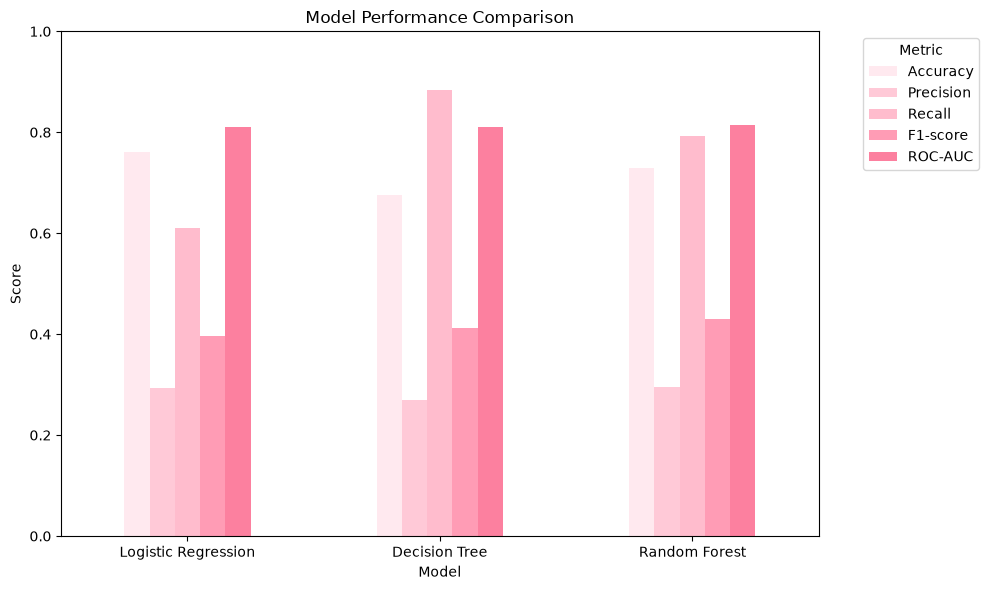

In [17]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

metric_colors = ["#FFE9EF", "#FFC9D7", "#FFBCCD", "#FF9CB5", "#FC809F"]

model_results_plot = model_results.set_index("Model")[metrics_to_plot]

ax = model_results_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=metric_colors
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The model comparison shows that Random Forest achieved the best overall balance across the evaluated metrics. It had the highest F1-score and ROC-AUC, while maintaining a strong recall for the terminated class.

The Decision Tree achieved the highest recall, meaning it identified the largest proportion of actual termination cases. However, it also produced more false positives and had lower overall accuracy.

Logistic Regression achieved the highest accuracy, but its recall was lower than the tree-based models, meaning it missed more actual attrition cases.

In [18]:
# Get feature names after preprocessing
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importances from the Random Forest model
importances = random_forest_model.named_steps["model"].feature_importances_

# Create a DataFrame with feature importances
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(20)

,feature,importance
1,num__tenure_days,0.187975
2,num__tenure_years,0.157468
61,cat__title_Area Sales Manager,0.034965
81,cat__title_Production Technician II,0.029294
21,cat__department_type_Production,0.028818
22,cat__department_type_Sales,0.028298
5,num__desired_salary,0.019987
10,num__training_cost,0.019214
179,cat__state_MA,0.017588
0,num__location_code,0.016981


In [19]:
feature_importance_df["feature_clean"] = (
    feature_importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

feature_importance_df[["feature_clean", "importance"]].head(20)

,feature_clean,importance
1,tenure_days,0.187975
2,tenure_years,0.157468
61,title_Area Sales Manager,0.034965
81,title_Production Technician II,0.029294
21,department_type_Production,0.028818
22,department_type_Sales,0.028298
5,desired_salary,0.019987
10,training_cost,0.019214
179,state_MA,0.017588
0,location_code,0.016981


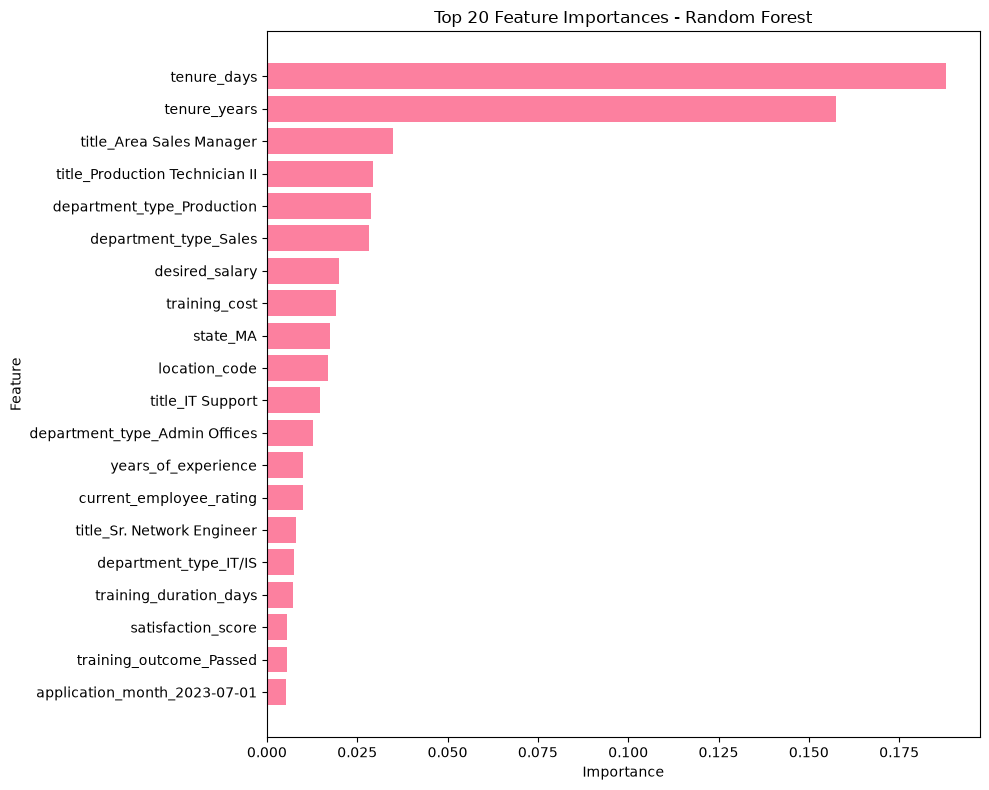

In [21]:
top_features = feature_importance_df.head(20).sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["feature_clean"],
    top_features["importance"],
    color="#FC809F"
)

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [22]:
# Feature set without tenure variables
leakage_risk_columns = [
    "tenure_days",
    "tenure_years"
]

X_no_tenure = X.drop(columns=leakage_risk_columns, errors="ignore")

numeric_features_no_tenure = X_no_tenure.select_dtypes(include=["number"]).columns.tolist()
categorical_features_no_tenure = X_no_tenure.select_dtypes(include=["object", "string", "bool"]).columns.tolist()

print("Features shape without tenure:", X_no_tenure.shape)
print("Numeric features:", len(numeric_features_no_tenure))
print("Categorical features:", len(categorical_features_no_tenure))

Features shape without tenure: (3000, 42)
Numeric features: 16
Categorical features: 26


In [23]:
X_train_nt, X_test_nt, y_train_nt, y_test_nt = train_test_split(
    X_no_tenure,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
numeric_transformer_nt = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_nt = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_nt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_nt, numeric_features_no_tenure),
        ("cat", categorical_transformer_nt, categorical_features_no_tenure)
    ]
)

In [25]:
random_forest_no_tenure_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nt),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

random_forest_no_tenure_model.fit(X_train_nt, y_train_nt)

evaluate_model(
    random_forest_no_tenure_model,
    X_test_nt,
    y_test_nt,
    "Random Forest without Tenure"
)

Model: Random Forest without Tenure
--------------------------------------------------
Accuracy: 0.6083
Precision: 0.1865
Recall: 0.6104
F1-score: 0.2857
ROC-AUC: 0.6581

Confusion Matrix:
[[318 205]
 [ 30  47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.61      0.73       523
           1       0.19      0.61      0.29        77

    accuracy                           0.61       600
   macro avg       0.55      0.61      0.51       600
weighted avg       0.82      0.61      0.67       600



### Random Forest Without Tenure Variables

After analyzing the feature importances of the first Random Forest model, `tenure_days` and `tenure_years` appeared as the two most important predictors.

This raised a potential data leakage concern. In the SQL project, tenure was calculated using the exit date for terminated employees and the current date for active employees. While this is appropriate for descriptive analysis, it may introduce information that would not be available at prediction time.

For this reason, a second Random Forest model was trained without tenure variables.

The model performance decreased substantially. ROC-AUC dropped from 0.8150 to 0.6581, and the F1-score decreased from 0.4296 to 0.2857. This suggests that tenure was contributing strongly to the predictive power of the original model.

Without tenure, the model still identified 61.04% of actual termination cases, but precision remained low. This indicates that the remaining variables have limited ability to predict attrition on their own.

Overall, the stricter model provides a more realistic view of the predictive limitations of the available dataset.

In [26]:
final_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest without Tenure"
    ],
    "Accuracy": [0.7617, 0.6767, 0.7300, 0.6083],
    "Precision": [0.2938, 0.2688, 0.2947, 0.1865],
    "Recall": [0.6104, 0.8831, 0.7922, 0.6104],
    "F1-score": [0.3966, 0.4121, 0.4296, 0.2857],
    "ROC-AUC": [0.8109, 0.8111, 0.8150, 0.6581]
})

final_model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7617,0.2938,0.6104,0.3966,0.8109
1,Decision Tree,0.6767,0.2688,0.8831,0.4121,0.8111
2,Random Forest,0.7300,0.2947,0.7922,0.4296,0.8150
3,Random Forest without Tenure,0.6083,0.1865,0.6104,0.2857,0.6581


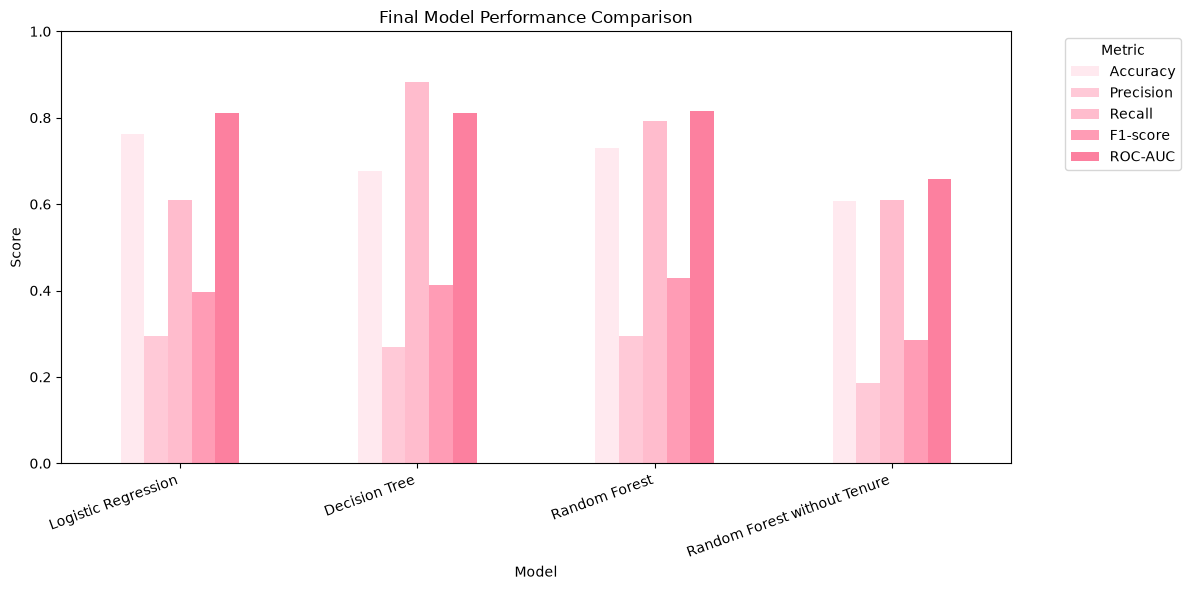

In [27]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

metric_colors = ["#FFE9EF", "#FFC9D7", "#FFBCCD", "#FF9CB5", "#FC809F"]

final_model_results_plot = final_model_results.set_index("Model")[metrics_to_plot]

ax = final_model_results_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color=metric_colors
)

plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Final Model Comparison

Two modeling perspectives were considered in this project.

The first perspective was an exploratory modeling approach, where tenure variables were included. In this version, Random Forest achieved the strongest overall performance, with the highest F1-score and ROC-AUC among the initial models.

However, the feature importance analysis showed that `tenure_days` and `tenure_years` were the two most important predictors. This raised a potential data leakage concern, because tenure had been calculated using the exit date for terminated employees and the current date for active employees.

For this reason, a second version of the Random Forest model was trained without tenure variables. This stricter model is more appropriate for evaluating the predictive power of the remaining employee profile, recruitment, engagement, training and performance variables.

The performance dropped substantially after removing tenure. ROC-AUC decreased from 0.8150 to 0.6581, and F1-score decreased from 0.4296 to 0.2857. This suggests that tenure was contributing strongly to the predictive power of the original model.

The final conclusion is that the Random Forest with tenure performs better as an exploratory model, while the Random Forest without tenure provides a more realistic view of the dataset's predictive limitations.

## Conclusion

This notebook extended the SQL employee lifecycle analysis into a predictive attrition modeling experiment.

Using the final SQL analytical view, `employee_lifecycle_summary`, several classification models were trained to predict employee termination. The models included Logistic Regression, Decision Tree and Random Forest.

The Random Forest model achieved the best overall balance among the initial models, with a ROC-AUC of 0.8150 and a recall of 0.7922 for the terminated class. This means the model was able to identify a large proportion of actual termination cases.

However, feature importance analysis revealed that tenure variables were the strongest predictors. Since tenure was calculated using exit dates for terminated employees, this introduced a potential data leakage concern.

After removing tenure variables, the Random Forest model performance decreased substantially. This suggests that the remaining variables, such as engagement, satisfaction, training, recruitment and performance indicators, have limited predictive power on their own in this dataset.

Overall, this project shows how SQL-generated analytical datasets can be reused for machine learning workflows in Python. It also highlights the importance of checking for data leakage, interpreting model results carefully and distinguishing between exploratory performance and realistic predictive performance.